# Advanced Mutual Fund Analytics

## Objective
This notebook performs advanced analytics on mutual fund and investor datasets, including:

1. Historical VaR (95%) and CVaR analysis
2. Rolling 90-Day Sharpe Ratio analysis
3. Investor Cohort Analysis
4. SIP Continuity Analysis
5. Risk-Based Fund Recommendation System
6. Sector Concentration Analysis using HHI
7. Advanced Business Insights

### Import Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

### Load Datasets

In [27]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

transactions = pd.read_csv(
    "../data/processed/08_investor_transactions_clean.csv"
)

performance = pd.read_csv(
    "../data/processed/07_scheme_performance_clean.csv"
)

holdings = pd.read_csv(
    "../data/processed/09_portfolio_holdings_clean.csv"
)
fund_master = pd.read_csv(
    "../data/processed/01_fund_master_clean.csv"
)

fund_master = fund_master[
    ['amfi_code', 'scheme_name']
]

print("All datasets loaded successfully")

All datasets loaded successfully


# Historical VaR and CVaR Analysis

Value at Risk (VaR) estimates the maximum expected loss at a given confidence level.

Conditional Value at Risk (CVaR) measures the average loss beyond the VaR threshold.

Confidence Level: 95%

In [28]:
# Convert date column
nav['date'] = pd.to_datetime(nav['date'])

# Sort values
nav = nav.sort_values(
    ['amfi_code', 'date']
)

# Calculate daily returns if not already present
if 'daily_return' not in nav.columns:

    nav['daily_return'] = (
        nav.groupby('amfi_code')['nav']
        .pct_change()
    )

# Store results
var_results = []

# Calculate VaR and CVaR for each fund
for code, group in nav.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    # Skip funds with insufficient history
    if len(returns) < 30:
        continue

    # Historical VaR (95%)
    var_95 = np.percentile(returns, 5)

    # Historical CVaR (95%)
    cvar_95 = returns[
        returns <= var_95
    ].mean()

    var_results.append({
        'amfi_code': code,
        'VaR_95': round(var_95, 6),
        'CVaR_95': round(cvar_95, 6)
    })

# Create DataFrame
var_df = pd.DataFrame(var_results)

# Merge with scheme names
var_df = var_df.merge(
    fund_master,
    on='amfi_code',
    how='left'
)

# Reorder columns
var_df = var_df[
    [
        'amfi_code',
        'scheme_name',
        'VaR_95',
        'CVaR_95'
    ]
]

# Sort by highest risk (most negative VaR)
var_df = var_df.sort_values(
    'VaR_95'
)

# Save report
var_df.to_csv(
    "../reports_adv_ana/var_cvar_report.csv",
    index=False
)

# Display top 10 riskiest funds
print("Top 10 Highest Risk Funds:\n")

display(var_df.head(10))

Top 10 Highest Risk Funds:



,amfi_code,scheme_name,VaR_95,CVaR_95
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384
17,119095,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
11,118634,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595
39,149324,DSP Small Cap Fund - Regular - Growth,-0.023483,-0.031036
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.019220,-0.023251
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
25,120505,ICICI Pru Midcap Fund - Regular - Growth,-0.018892,-0.024342
16,119094,Axis Midcap Fund - Regular - Growth,-0.018480,-0.024260


# Rolling 90-Day Sharpe Ratio

Rolling Sharpe Ratio measures changing risk-adjusted performance over time.

Formula:

Sharpe = Mean(Returns) / Std(Returns) × √252

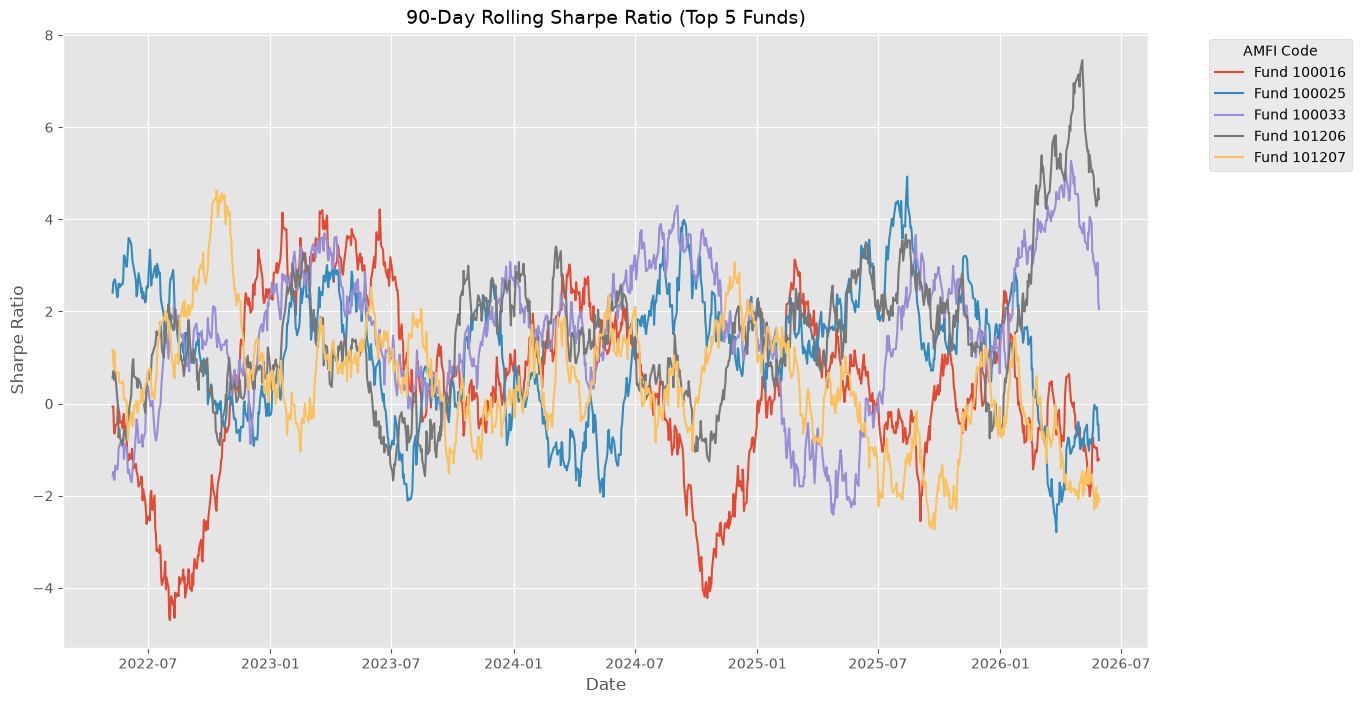

✅ Rolling Sharpe chart saved successfully!


In [29]:
# Convert date column to datetime
nav['date'] = pd.to_datetime(nav['date'])

# Sort data
nav = nav.sort_values(['amfi_code', 'date'])

# Calculate daily returns if missing
if 'daily_return' not in nav.columns:

    nav['daily_return'] = (
        nav.groupby('amfi_code')['nav']
        .pct_change()
    )

# Select first 5 funds
top_funds = nav['amfi_code'].unique()[:5]

# Create plot
plt.figure(figsize=(14, 8))

for code in top_funds:

    fund = nav[
        nav['amfi_code'] == code
    ].copy()

    # Calculate 90-day rolling Sharpe Ratio
    rolling_sharpe = (
        fund['daily_return']
        .rolling(window=90)
        .mean()
        /
        fund['daily_return']
        .rolling(window=90)
        .std()
    ) * np.sqrt(252)

    # Plot
    plt.plot(
        fund['date'],
        rolling_sharpe,
        label=f"Fund {code}"
    )

# Chart formatting
plt.title(
    "90-Day Rolling Sharpe Ratio (Top 5 Funds)",
    fontsize=14
)

plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.legend(
    title="AMFI Code",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.grid(True)

# Save chart
plt.savefig(
    "../charts/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("✅ Rolling Sharpe chart saved successfully!")

# Investor Cohort Analysis

Investors are grouped according to their first investment year.

Metrics:

- Average Investment Amount
- Total Investment
- Most Preferred Fund

In [30]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

# First investment year
transactions['cohort_year'] = (
    transactions
    .groupby('investor_id')['transaction_date']
    .transform('min')
    .dt.year
)

# Average and total investment
cohort_summary = (
    transactions
    .groupby('cohort_year')
    .agg(
        avg_investment=('amount_inr', 'mean'),
        total_invested=('amount_inr', 'sum')
    )
    .reset_index()
)

# Top fund preference
top_funds = (
    transactions
    .groupby(['cohort_year', 'amfi_code'])
    .size()
    .reset_index(name='count')
)

top_pref = top_funds.loc[
    top_funds.groupby('cohort_year')['count'].idxmax()
]

cohort_summary = cohort_summary.merge(
    top_pref[['cohort_year', 'amfi_code']],
    on='cohort_year',
    how='left'
)

cohort_summary.rename(
    columns={'amfi_code': 'top_fund'},
    inplace=True
)

# Save report
cohort_summary.to_csv(
    "../reports_adv_ana/cohort_analysis.csv",
    index=False
)

cohort_summary.head()

,cohort_year,avg_investment,total_invested,top_fund
0,2024,107422.541832,3491125187,148568
1,2025,109158.577061,30455243,119599


# SIP Continuity Analysis

Investors with:

- Minimum 6 SIP transactions
- Average gap greater than 35 days

are classified as At-Risk.

In [31]:
sip = transactions[
    transactions['transaction_type'] == 'SIP'
].copy()

results = []

for investor, group in sip.groupby('investor_id'):

    if len(group) >= 6:

        group = group.sort_values(
            'transaction_date'
        )

        gaps = (
            group['transaction_date']
            .diff()
            .dt.days
            .dropna()
        )

        avg_gap = gaps.mean()

        status = (
            "At-Risk"
            if avg_gap > 35
            else "Active"
        )

        results.append({
            "investor_id": investor,
            "avg_gap_days": round(avg_gap, 2),
            "status": status
        })

sip_continuity = pd.DataFrame(results)

sip_continuity.to_csv(
    "../reports_adv_ana/sip_continuity_report.csv",
    index=False
)

sip_continuity.head()

,investor_id,avg_gap_days,status
0,INV000004,85.40,At-Risk
1,INV000008,70.40,At-Risk
2,INV000010,64.80,At-Risk
3,INV000011,40.17,At-Risk
4,INV000012,57.00,At-Risk


# Sector Concentration Analysis

Herfindahl-Hirschman Index (HHI):

HHI = Σ(weight²)

Higher values indicate more concentrated portfolios.

✅ sector_hhi_report.csv saved


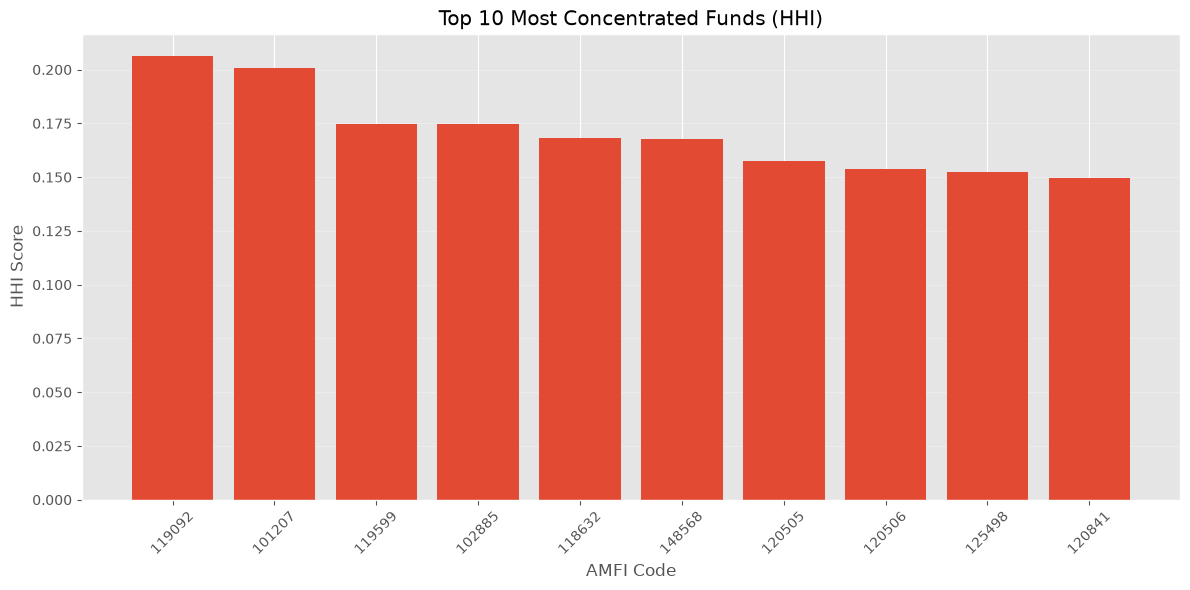

✅ sector_hhi_comparison.png saved


In [32]:
#Calculate HHI for each fund
hhi = (
    holdings
    .groupby('amfi_code')['weight_pct']
    .apply(lambda x: ((x / 100) ** 2).sum())
    .reset_index()
)

# Rename columns
hhi.columns = ['amfi_code', 'HHI']

# Sort by concentration (highest first)
hhi = hhi.sort_values(
    'HHI',
    ascending=False
)

# Save complete HHI report
hhi.to_csv(
    "../reports_adv_ana/sector_hhi_report.csv",
    index=False
)

print("✅ sector_hhi_report.csv saved")

# -------------------------------------
# Create HHI comparison chart
# -------------------------------------

# Plot top 10 most concentrated funds
top_hhi = hhi.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_hhi['amfi_code'].astype(str),
    top_hhi['HHI']
)

plt.title("Top 10 Most Concentrated Funds (HHI)")
plt.xlabel("AMFI Code")
plt.ylabel("HHI Score")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../charts/sector_hhi_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("✅ sector_hhi_comparison.png saved")

# Advanced Insights

## 1. VaR & CVaR Analysis
Funds with the most negative VaR values demonstrate higher downside risk during volatile market periods.

## 2. Rolling Sharpe Performance
The selected funds exhibit varying levels of risk-adjusted returns over time, with some maintaining more stable Sharpe ratios.

## 3. Investor Cohorts
Certain investor cohorts contribute significantly higher investment volumes, indicating changing retail participation trends.

## 4. SIP Continuity
Investors with average gaps greater than 35 days have been classified as at-risk, helping identify potential SIP discontinuation patterns.

## 5. Portfolio Concentration
Funds with higher HHI values possess more concentrated holdings, potentially increasing concentration risk compared to diversified schemes.